#

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as spicy

In the Central Limit Theorem notes, we learned a framework for which we
can bound an expectation. However, we don’t want to rely on knowledge of
the standard deviation. When you have to estimate the standard
deviation, in order to bound with a confidence interval, the
expectation, we must use the formula

$$\bar{X} \pm t_{N-1} s / \sqrt{N}$$

where $t_{N-1}$ is found from the t-distribution. If $N = 10$, then we
could use the following code to find $t_{N-1}$

In [4]:
spicy.t(df = 10 - 1).ppf(0.975) # for 95% confidence interval

2.262157162854099

In [5]:
rng = np.random.default_rng()

In [27]:
N = 1000
R = 10_000
b = np.zeros(R)
n = 11
p = 0.75
E = n * p
for r in range(R):
    x = rng.binomial(n, p, size = N)
    xbar = np.mean(x)
    t = spicy.t(df = N - 1).ppf(0.95) # t-distribution to acccount
    # for estimating mean and standard deviation (two things)
    s = np.std(x)
    lb = xbar - t * s / np.sqrt(N)
    ub = xbar + t * s / np.sqrt(N)
    b[r] = lb <= E <=  ub # Bernoulli

In [28]:
np.mean(b)

0.8932

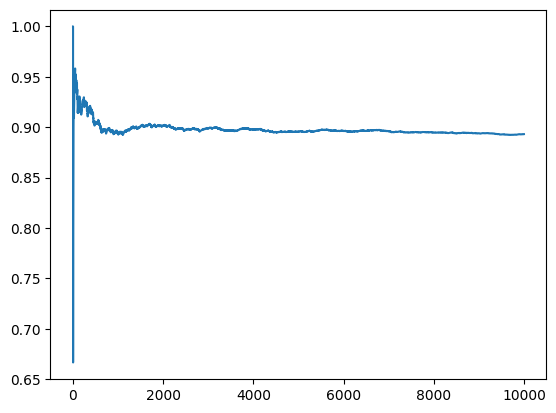

In [30]:
rdx = np.arange(1, R+1)
cm = np.cumsum(b) / rdx
plt.plot(rdx, cm);